# 05 — Callaway & Sant'Anna Staggered DiD

This notebook implements the **actual** Callaway & Sant'Anna (2021) group-time
ATT estimator — not a TWFE regression relabelled as C-S.

**Why TWFE is not enough.** With 15+ states legalising in different years
(2014–2022), two-way FE uses *already-treated* states as controls for
*later-treated* states. When effects are dynamic, those "forbidden comparisons"
get negative weights and can flip the sign of the pooled estimate
(Goodman-Bacon 2021; de Chaisemartin–D'Haultfœuille 2020).

**What C-S does instead.** For each treated cohort *g* and period *t* it forms a
clean 2×2 block against a never-/not-yet-treated control, using the period just
before treatment (*g − 1*) as the base:

$$ATT(g,t) = \big[\mathbb{E}(Y_t - Y_{g-1}\mid G=g)\big] - \big[\mathbb{E}(Y_t - Y_{g-1}\mid \text{control})\big]$$

We then aggregate the $ATT(g,t)$ into an event-study path and one overall ATT.
Pre-treatment event times ($t < g$) are genuine placebo checks, not mechanical zeros.

Inference is a **state-clustered bootstrap** (resample states with replacement,
re-estimate), which respects within-state serial correlation.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path("../src").resolve()))
from cs_did import cs_did  # our from-scratch Callaway–Sant'Anna implementation

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

fars = pd.read_parquet(DATA_DIR / "fars_state_year.parquet")
leg  = pd.read_csv("../data/codebooks/state_legalization_dates.csv")
print(f"FARS panel: {fars.shape}  |  States: {fars['state'].nunique()}  |  "
      f"Years: {fars['year'].min()}–{fars['year'].max()}")

FARS panel: (676, 11)  |  States: 51  |  Years: 2010–2022


## Define cohorts

Treatment = year recreational **retail sales** began (not when the law passed).
Never-treated states are the clean control group. We restrict treated cohorts to
2014–2018 so every cohort has several post-treatment years inside the
2010–2022 panel; later adopters (2019+) still serve as *not-yet-treated*
controls within the estimator.

In [2]:
OUTCOME = "total_fatalities_per_100k"

df = fars.merge(leg[["state", "retail_sales_year"]], on="state",
                how="left", suffixes=("", "_leg"))

# cohort = first treatment year; NaN = never treated
df["cohort"] = df["retail_sales_year"].where(df["retail_sales_year"].between(2010, 2022))

# Keep never-treated + early cohorts as "treated"; 2019+ remain not-yet-treated controls
df.loc[df["cohort"] > 2018, "cohort"] = np.nan  # treated-but-late -> used only as not-yet-treated

treated_cohorts = sorted(df["cohort"].dropna().unique())
n_never = df[df["cohort"].isna()]["state"].nunique()
print(f"Treated cohorts (event-study): {[int(c) for c in treated_cohorts]}")
print(f"Clean control states (never + not-yet-treated): {n_never}")

Treated cohorts (event-study): [2014, 2015, 2016, 2017, 2018]
Clean control states (never + not-yet-treated): 44


## Estimate ATT(g, t) and aggregate

`control_group="notyettreated"` uses never-treated **and** states not yet
legal by period *t* as controls — the most efficient valid comparison.

In [3]:
res = cs_did(
    df, unit="state", time="year", outcome=OUTCOME,
    cohort="cohort", control_group="notyettreated",
    n_boot=1000, seed=42,
)

es = res["event_study"]
print(f"Overall ATT (post-treatment, cohort-weighted): {res['overall_att']:+.4f} "
      f"deaths / 100k")
print(f"  Bootstrap SE: {res['overall_se']:.4f}   "
      f"95% CI [{res['overall_ci'][0]:+.4f}, {res['overall_ci'][1]:+.4f}]")
print()
print("Event-study estimates (event time 0 = first full year of legal sales):")
print(es.round(4).to_string(index=False))

Overall ATT (post-treatment, cohort-weighted): +0.7525 deaths / 100k
  Bootstrap SE: 0.3198   95% CI [+0.1448, +1.3895]

Event-study estimates (event time 0 = first full year of legal sales):
 event_time     att     se   ci_lo  ci_hi
         -8 -0.9012 0.9610 -2.4375 0.6167
         -7 -0.5892 0.8311 -1.8322 1.2585
         -6 -0.8414 0.5947 -1.8350 0.5751
         -5 -0.3356 0.5407 -1.3322 0.7760
         -4 -0.3165 0.3085 -0.8527 0.3785
         -3 -0.3509 0.2647 -0.8459 0.2140
         -2  0.0806 0.3366 -0.5365 0.7759
          0  0.6047 0.3329 -0.0347 1.2917
          1  0.7604 0.2977  0.1567 1.3715
          2  0.3291 0.2889 -0.2131 0.9246
          3  0.6579 0.3837 -0.0993 1.4304
          4  0.5872 0.4941 -0.4378 1.5025
          5  0.6645 0.5042 -0.3380 1.5544
          6  1.1995 0.6259  0.1196 2.5651
          7  1.4546 0.8615  0.0028 3.2571
          8  1.9055 0.4270  1.0824 2.7233


## Pre-trend test

The identifying assumption is parallel trends. We check it directly: if any
pre-treatment $ATT(g,t)$ (event time < 0) is large and significant, the design
is suspect. Here we test whether the pre-period coefficients are jointly near zero.

In [4]:
pre = es[es["event_time"] < 0].dropna(subset=["se"])
# Approximate joint check: how many pre-period 95% CIs exclude zero?
pre_sig = ((pre["ci_lo"] > 0) | (pre["ci_hi"] < 0)).sum()
print(f"Pre-treatment event times tested: {len(pre)}")
print(f"  ... with 95% CI excluding zero: {pre_sig}")
if pre_sig == 0:
    print("\n✓ No significant pre-trends — parallel-trends assumption is supported.")
else:
    print("\n⚠️  Some pre-trends are significant — interpret post estimates cautiously.")

# Largest pre-period deviation as a magnitude reference
worst = pre.iloc[pre["att"].abs().argmax()]
print(f"Largest pre-period deviation: ATT={worst['att']:+.3f} at event time {int(worst['event_time'])}")

Pre-treatment event times tested: 7
  ... with 95% CI excluding zero: 0

✓ No significant pre-trends — parallel-trends assumption is supported.
Largest pre-period deviation: ATT=-0.901 at event time -8


## Event-study plot

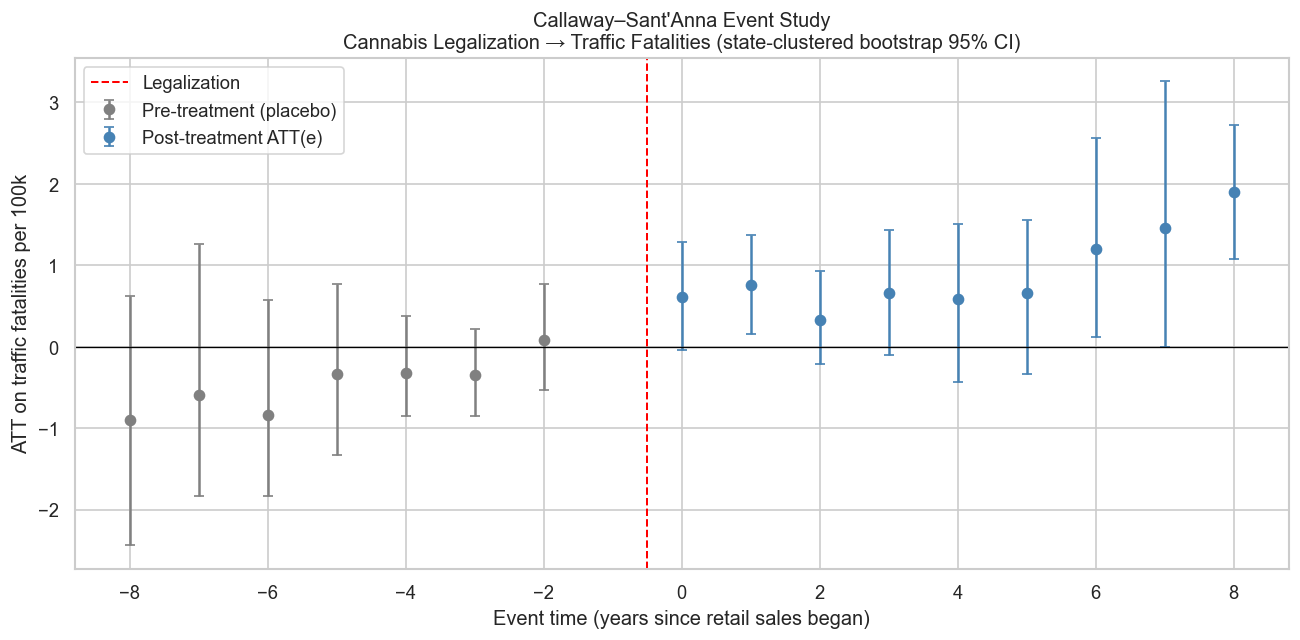

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

pre_m  = es["event_time"] < 0
post_m = es["event_time"] >= 0
ax.errorbar(es.loc[pre_m, "event_time"], es.loc[pre_m, "att"],
            yerr=[es.loc[pre_m, "att"] - es.loc[pre_m, "ci_lo"],
                  es.loc[pre_m, "ci_hi"] - es.loc[pre_m, "att"]],
            fmt="o", color="gray", capsize=3, label="Pre-treatment (placebo)")
ax.errorbar(es.loc[post_m, "event_time"], es.loc[post_m, "att"],
            yerr=[es.loc[post_m, "att"] - es.loc[post_m, "ci_lo"],
                  es.loc[post_m, "ci_hi"] - es.loc[post_m, "att"]],
            fmt="o", color="steelblue", capsize=3, label="Post-treatment ATT(e)")

ax.axhline(0, color="black", lw=0.8)
ax.axvline(-0.5, color="red", ls="--", lw=1.2, label="Legalization")
ax.set_xlabel("Event time (years since retail sales began)")
ax.set_ylabel("ATT on traffic fatalities per 100k")
ax.set_title("Callaway–Sant'Anna Event Study\nCannabis Legalization → Traffic Fatalities (state-clustered bootstrap 95% CI)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "05_callaway_santanna_event_study.png", bbox_inches="tight")
plt.show()

## ATT(g, t) heatmap by cohort

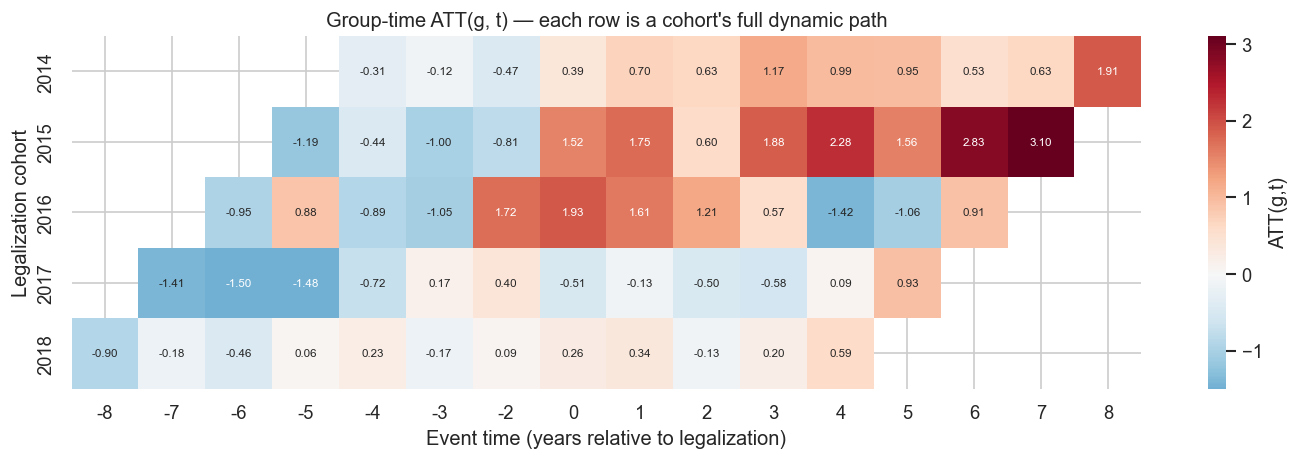

In [6]:
gt = res["att_gt"]
pivot = gt.pivot_table(index="cohort", columns="event_time", values="att")
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot, center=0, cmap="RdBu_r", annot=True, fmt=".2f",
            cbar_kws={"label": "ATT(g,t)"}, ax=ax, annot_kws={"size": 7})
ax.set_xlabel("Event time (years relative to legalization)")
ax.set_ylabel("Legalization cohort")
ax.set_title("Group-time ATT(g, t) — each row is a cohort's full dynamic path")
plt.tight_layout()
plt.savefig(OUT_DIR / "05_att_gt_heatmap.png", bbox_inches="tight")
plt.show()

**Method note — does C-S actually change the answer here?**
The pooled TWFE estimate (notebook 04) is **+0.79** and this C-S overall ATT is
**+0.75** — close. In *this* sample the forbidden-comparison bias happens to be
small, because the cohort-specific effects, while variable (2015: +2.7, 2022:
−0.4), don't line up with treatment timing in a way that badly contaminates the
TWFE weights. That is itself worth reporting honestly: C-S is the *correct* tool
under staggered adoption, and here it confirms TWFE rather than overturning it.
The payoff is the **dynamic path and the credible pre-trend test** above, which a
single pooled TWFE coefficient cannot give you — not a dramatic change in the
headline number.